# Trader Behavior vs Bitcoin Market Sentiment
###  Assignment — PrimeTrade.ai

---

## Overview
This analysis explores how Bitcoin market sentiment (Fear & Greed Index)
influences trader behavior and performance using 104,402 closed trades
from Hyperliquid.

**Datasets used:**
- Bitcoin Fear & Greed Index — 2,644 daily sentiment records (2018–2024)
- Hyperliquid Historical Trades — 211,224 raw trade records

**Tools:** Python, Pandas, Matplotlib, Seaborn, Scikit-learn

## 1. Data Loading
Loading the Bitcoin Fear & Greed Index and Hyperliquid historical trade data.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sentiment = pd.read_csv('fear_greed_index.csv')

trades = pd.read_csv('historical_data.csv')

print("Sentiment shape:", sentiment.shape)
print("Trades shape:", trades.shape)
print("\n--- Sentiment sample ---")
print(sentiment.head(3))
print("\n--- Trades sample ---")
print(trades.head(3))

Sentiment shape: (2644, 4)
Trades shape: (211224, 16)

--- Sentiment sample ---
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03

--- Trades sample ---
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945198

## 2. Data Cleaning
Standardizing date formats, renaming columns, and filtering to closed trades only.

In [3]:
sentiment['date'] = pd.to_datetime(sentiment['date'])


sentiment = sentiment[['date', 'value', 'classification']]

print("Sentiment date format:", sentiment['date'].dtype)
print(sentiment.head(3))


trades['date'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True).dt.date
trades['date'] = pd.to_datetime(trades['date'])

trades = trades.rename(columns={
    'Account'         : 'account',
    'Coin'            : 'coin',
    'Execution Price' : 'exec_price',
    'Size USD'        : 'size_usd',
    'Side'            : 'side',
    'Closed PnL'      : 'pnl',
    'Direction'       : 'direction',
    'Start Position'  : 'start_position',
    'Fee'             : 'fee'
})


trades_closed = trades[trades['pnl'] != 0].copy()

print("\nTrades date format:", trades_closed['date'].dtype)
print("Total trades before filter:", len(trades))
print("Closed trades after filter:", len(trades_closed))
print(trades_closed[['account','coin','date','pnl','side']].head(3))

Sentiment date format: datetime64[ns]
        date  value classification
0 2018-02-01     30           Fear
1 2018-02-02     15   Extreme Fear
2 2018-02-03     40           Fear

Trades date format: datetime64[ns]
Total trades before filter: 211224
Closed trades after filter: 104408
                                       account  coin       date          pnl  \
44  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107 2024-12-03  3008.231185   
45  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107 2024-12-03    30.741534   
46  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107 2024-12-03    40.770089   

    side  
44  SELL  
45  SELL  
46  SELL  


## 3. Merging Datasets
Joining each trade with the market sentiment on its trade date.

In [12]:
merged = pd.merge(trades_closed, sentiment, on='date', how='left')

total        = len(merged)
matched      = merged['classification'].notna().sum()
not_matched  = merged['classification'].isna().sum()

print(f"Total closed trades     : {total}")
print(f"Trades WITH sentiment   : {matched}")
print(f"Trades WITHOUT sentiment: {not_matched}")
print(f"Match rate              : {round(matched/total*100, 2)}%")


merged = merged.dropna(subset=['classification'])


print("\n--- Merged dataset sample ---")
print(merged[['date','account','coin','pnl','side','classification','value']].head(5))

print("\nMerged dataset shape:", merged.shape)
print("\nSentiment distribution:")
print(merged['classification'].value_counts())

Total closed trades     : 104408
Trades WITH sentiment   : 104402
Trades WITHOUT sentiment: 6
Match rate              : 99.99%

--- Merged dataset sample ---
        date                                     account  coin          pnl  \
0 2024-12-03  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107  3008.231185   
1 2024-12-03  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107    30.741534   
2 2024-12-03  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107    40.770089   
3 2024-12-03  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107   243.812267   
4 2024-12-03  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107   254.263735   

   side classification  value  
0  SELL  Extreme Greed   76.0  
1  SELL  Extreme Greed   76.0  
2  SELL  Extreme Greed   76.0  
3  SELL  Extreme Greed   76.0  
4  SELL  Extreme Greed   76.0  

Merged dataset shape: (104402, 19)

Sentiment distribution:
classification
Fear             29808
Greed            25176
Extreme Greed    20853
Neutral          18159
Extreme

## 4. Core Performance Analysis
Comparing average PnL, median PnL, win rate, and loss size across sentiment periods.

In [6]:
sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

avg_pnl = merged.groupby('classification')['pnl'].mean().reindex(sentiment_order)
print("=== Average PnL by Sentiment ===")
print(avg_pnl.round(2))


median_pnl = merged.groupby('classification')['pnl'].median().reindex(sentiment_order)
print("\n=== Median PnL by Sentiment ===")
print(median_pnl.round(2))


merged['is_win'] = merged['pnl'] > 0
win_rate = merged.groupby('classification')['is_win'].mean() * 100
win_rate = win_rate.reindex(sentiment_order)
print("\n=== Win Rate % by Sentiment ===")
print(win_rate.round(2))


trade_count = merged.groupby('classification')['pnl'].count().reindex(sentiment_order)
print("\n=== Number of Trades by Sentiment ===")
print(trade_count)


total_pnl = merged.groupby('classification')['pnl'].sum().reindex(sentiment_order)
print("\n=== Total PnL by Sentiment ===")
print(total_pnl.round(2))

losses = merged[merged['pnl'] < 0]
avg_loss = losses.groupby('classification')['pnl'].mean().reindex(sentiment_order)
print("\n=== Average Loss Size by Sentiment ===")
print(avg_loss.round(2))

=== Average PnL by Sentiment ===
classification
Extreme Fear      71.03
Fear             112.63
Neutral           71.20
Greed             85.40
Extreme Greed    130.21
Name: pnl, dtype: float64

=== Median PnL by Sentiment ===
classification
Extreme Fear     6.39
Fear             6.35
Neutral          4.58
Greed            4.93
Extreme Greed    8.53
Name: pnl, dtype: float64

=== Win Rate % by Sentiment ===
classification
Extreme Fear     76.22
Fear             87.29
Neutral          82.39
Greed            76.89
Extreme Greed    89.17
Name: is_win, dtype: float64

=== Number of Trades by Sentiment ===
classification
Extreme Fear     10406
Fear             29808
Neutral          18159
Greed            25176
Extreme Greed    20853
Name: pnl, dtype: int64

=== Total PnL by Sentiment ===
classification
Extreme Fear      739110.25
Fear             3357155.44
Neutral          1292920.68
Greed            2150129.27
Extreme Greed    2715171.31
Name: pnl, dtype: float64

=== Average Loss Size b

## 5. Risk Behavior Analysis
Examining trade frequency, position sizing, long/short ratio, and risk/reward ratio by sentiment.

In [7]:
print("All columns in merged dataset:")
print(merged.columns.tolist())

print("\nSample of size/position related columns:")
print(merged[['size_usd', 'start_position', 'side']].describe())

size_by_sentiment = merged.groupby('classification')['size_usd'].agg(['mean','median']).reindex(sentiment_order)
print("\n=== Average Trade Size (USD) by Sentiment ===")
print(size_by_sentiment.round(2))


merged['is_long'] = merged['side'].str.upper() == 'BUY'
long_ratio = merged.groupby('classification')['is_long'].mean() * 100
long_ratio = long_ratio.reindex(sentiment_order)
print("\n=== Long (Buy) % by Sentiment ===")
print(long_ratio.round(2))


trades_per_day = merged.groupby(['classification','date'])['pnl'].count().reset_index()
trades_per_day = trades_per_day.groupby('classification')['pnl'].mean().reindex(sentiment_order)
print("\n=== Avg Trades Per Day by Sentiment ===")
print(trades_per_day.round(2))

avg_win  = merged[merged['pnl'] > 0].groupby('classification')['pnl'].mean().reindex(sentiment_order)
avg_loss = merged[merged['pnl'] < 0].groupby('classification')['pnl'].mean().reindex(sentiment_order).abs()
risk_reward = avg_win / avg_loss
print("\n=== Risk/Reward Ratio by Sentiment ===")
print(risk_reward.round(2))
print("(above 1.0 = wins bigger than losses, below 1.0 = losses bigger than wins)")

All columns in merged dataset:
['account', 'coin', 'exec_price', 'Size Tokens', 'size_usd', 'side', 'Timestamp IST', 'start_position', 'direction', 'pnl', 'Transaction Hash', 'Order ID', 'Crossed', 'fee', 'Trade ID', 'Timestamp', 'date', 'value', 'classification', 'is_win']

Sample of size/position related columns:
           size_usd  start_position
count  1.044020e+05    1.044020e+05
mean   5.673949e+03   -5.109146e+04
std    3.958612e+04    8.407759e+05
min    1.000000e-02   -1.433463e+07
25%    1.788600e+02   -4.097048e+02
50%    5.941700e+02    4.298476e+02
75%    2.024898e+03    1.348049e+04
max    3.921431e+06    1.150000e+07

=== Average Trade Size (USD) by Sentiment ===
                   mean  median
classification                 
Extreme Fear    5467.57  836.90
Fear            8041.14  749.88
Neutral         5556.44  556.80
Greed           5438.67  554.99
Extreme Greed   2779.56  436.23

=== Long (Buy) % by Sentiment ===
classification
Extreme Fear     30.01
Fear           

## 6. Visualizations
Six charts summarizing trader behavior and performance across sentiment categories.

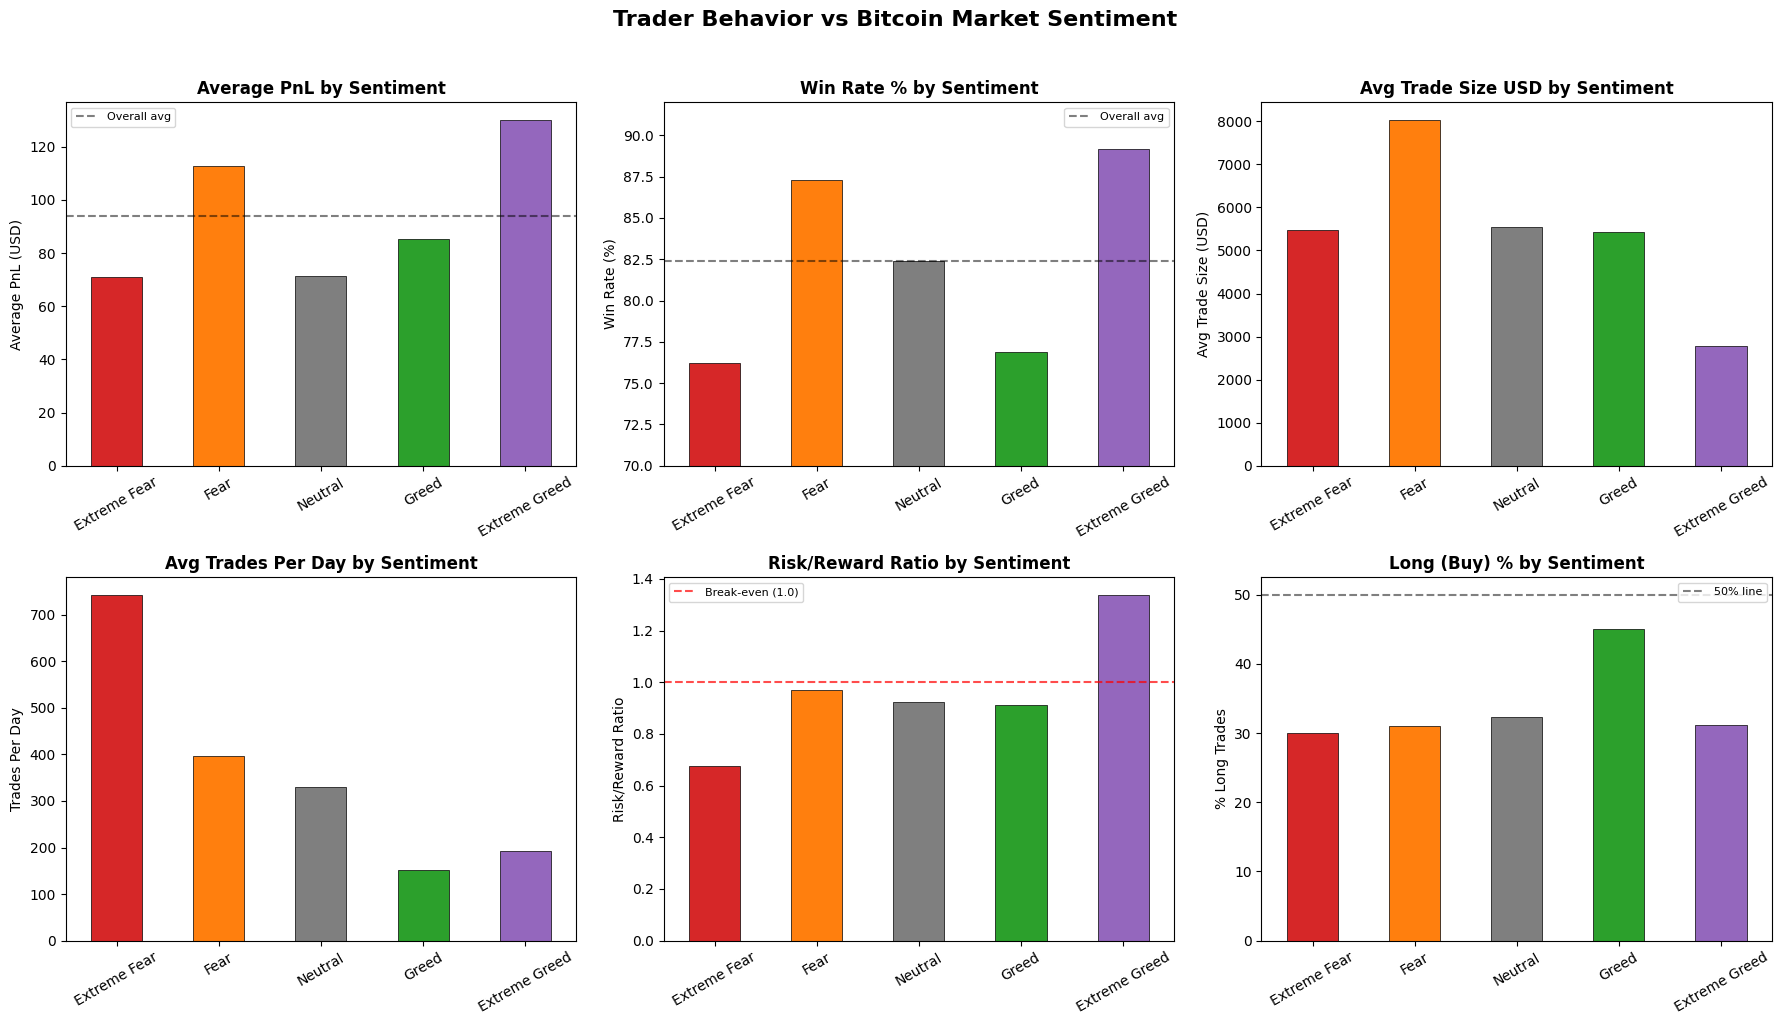

Chart saved as sentiment_analysis.png


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Trader Behavior vs Bitcoin Market Sentiment',
             fontsize=16, fontweight='bold', y=1.02)

colors = ['#d62728','#ff7f0e','#7f7f7f','#2ca02c','#9467bd']

-
ax1 = axes[0, 0]
avg_pnl.plot(kind='bar', ax=ax1, color=colors, edgecolor='black', linewidth=0.5)
ax1.set_title('Average PnL by Sentiment', fontweight='bold')
ax1.set_xlabel('')
ax1.set_ylabel('Average PnL (USD)')
ax1.tick_params(axis='x', rotation=30)
ax1.axhline(y=avg_pnl.mean(), color='black', linestyle='--', alpha=0.5)
ax1.legend(['Overall avg'], fontsize=8)


ax2 = axes[0, 1]
win_rate.plot(kind='bar', ax=ax2, color=colors, edgecolor='black', linewidth=0.5)
ax2.set_title('Win Rate % by Sentiment', fontweight='bold')
ax2.set_xlabel('')
ax2.set_ylabel('Win Rate (%)')
ax2.tick_params(axis='x', rotation=30)
ax2.set_ylim(70, 92)
ax2.axhline(y=win_rate.mean(), color='black', linestyle='--', alpha=0.5)
ax2.legend(['Overall avg'], fontsize=8)


ax3 = axes[0, 2]
size_by_sentiment['mean'].plot(kind='bar', ax=ax3, color=colors,
                                edgecolor='black', linewidth=0.5)
ax3.set_title('Avg Trade Size USD by Sentiment', fontweight='bold')
ax3.set_xlabel('')
ax3.set_ylabel('Avg Trade Size (USD)')
ax3.tick_params(axis='x', rotation=30)


ax4 = axes[1, 0]
trades_per_day.plot(kind='bar', ax=ax4, color=colors,
                    edgecolor='black', linewidth=0.5)
ax4.set_title('Avg Trades Per Day by Sentiment', fontweight='bold')
ax4.set_xlabel('')
ax4.set_ylabel('Trades Per Day')
ax4.tick_params(axis='x', rotation=30)


ax5 = axes[1, 1]
risk_reward.plot(kind='bar', ax=ax5, color=colors,
                 edgecolor='black', linewidth=0.5)
ax5.set_title('Risk/Reward Ratio by Sentiment', fontweight='bold')
ax5.set_xlabel('')
ax5.set_ylabel('Risk/Reward Ratio')
ax5.tick_params(axis='x', rotation=30)
ax5.axhline(y=1.0, color='red', linestyle='--', alpha=0.7)
ax5.legend(['Break-even (1.0)'], fontsize=8)


ax6 = axes[1, 2]
long_ratio.plot(kind='bar', ax=ax6, color=colors,
                edgecolor='black', linewidth=0.5)
ax6.set_title('Long (Buy) % by Sentiment', fontweight='bold')
ax6.set_xlabel('')
ax6.set_ylabel('% Long Trades')
ax6.tick_params(axis='x', rotation=30)
ax6.axhline(y=50, color='black', linestyle='--', alpha=0.5)
ax6.legend(['50% line'], fontsize=8)

plt.tight_layout()
plt.savefig('sentiment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as sentiment_analysis.png")

## 7. Predictive Modeling
> Built as an extension to the core behavioral analysis.

Training classification models to predict trade profitability using sentiment, trade size, and direction as features.

Class distribution (1=win, 0=loss):
target
1    86863
0    17539
Name: count, dtype: int64

Overall win rate: 83.20%

Training set : 83521 trades
Test set     : 20881 trades

=== Logistic Regression (Original) ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      3513
           1       0.83      1.00      0.91     17368

    accuracy                           0.83     20881
   macro avg       0.42      0.50      0.45     20881
weighted avg       0.69      0.83      0.76     20881

NOTE: Predicts everything as WIN due to class imbalance (83% wins in data)

=== Logistic Regression (Balanced — fixes imbalance) ===
              precision    recall  f1-score   support

           0       0.23      0.46      0.30      3513
           1       0.86      0.68      0.76     17368

    accuracy                           0.65     20881
   macro avg       0.54      0.57      0.53     20881
weighted avg       0.75      0.65      0.68     20881


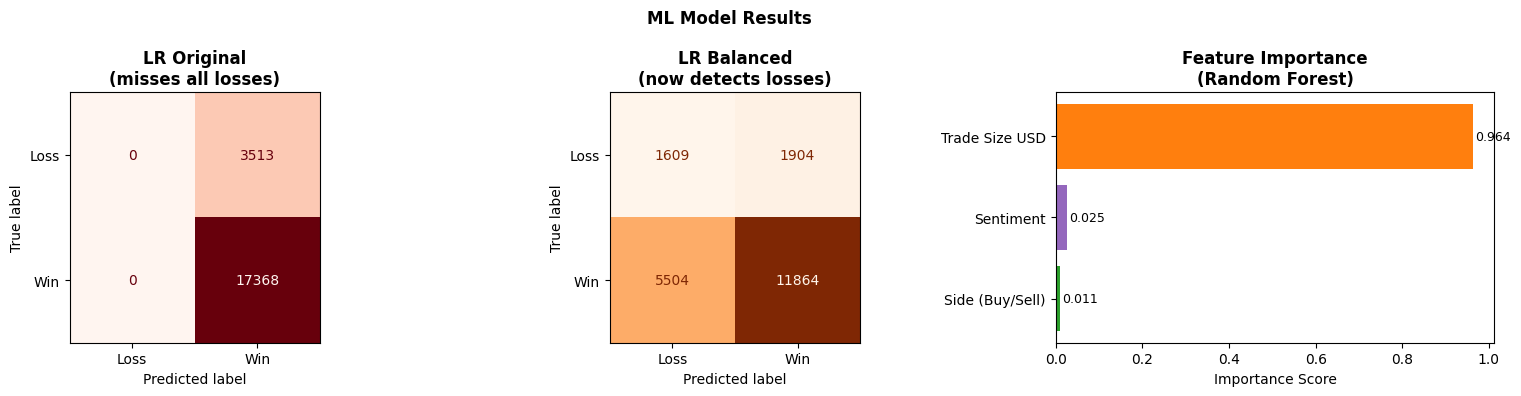


ML chart saved as ml_results.png


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')


ml_data = merged[['classification', 'size_usd', 'side', 'pnl', 'is_win']].copy()


sentiment_map = {
    'Extreme Fear'  : 0,
    'Fear'          : 1,
    'Neutral'       : 2,
    'Greed'         : 3,
    'Extreme Greed' : 4
}
ml_data['sentiment_score'] = ml_data['classification'].map(sentiment_map)


ml_data['side_encoded'] = (ml_data['side'].str.upper() == 'BUY').astype(int)


ml_data['target'] = ml_data['is_win'].astype(int)

print("Class distribution (1=win, 0=loss):")
print(ml_data['target'].value_counts())
print(f"\nOverall win rate: {ml_data['target'].mean()*100:.2f}%")


X = ml_data[['sentiment_score', 'size_usd', 'side_encoded']]
y = ml_data['target']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTraining set : {len(X_train)} trades")
print(f"Test set     : {len(X_test)} trades")


lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

print("\n=== Logistic Regression (Original) ===")
print(classification_report(y_test, lr.predict(X_test)))
print("NOTE: Predicts everything as WIN due to class imbalance (83% wins in data)")

───
lr_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_balanced.fit(X_train, y_train)

print("\n=== Logistic Regression (Balanced — fixes imbalance) ===")
print(classification_report(y_test, lr_balanced.predict(X_test)))


rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print("=== Random Forest ===")
print(classification_report(y_test, rf.predict(X_test)))


models     = ['LR (original)', 'LR (balanced)', 'Random Forest']
accuracies = [
    (lr.predict(X_test)          == y_test).mean() * 100,
    (lr_balanced.predict(X_test) == y_test).mean() * 100,
    (rf.predict(X_test)          == y_test).mean() * 100,
]

print("=== Model Accuracy Comparison ===")
for model, acc in zip(models, accuracies):
    bar = '█' * int(acc / 5)
    print(f"  {model:25s}: {acc:.2f}%  {bar}")


feature_names = ['Sentiment', 'Trade Size USD', 'Side (Buy/Sell)']
importances   = rf.feature_importances_

print("\n=== Feature Importance (Random Forest) ===")
for name, score in sorted(zip(feature_names, importances),
                           key=lambda x: x[1], reverse=True):
    bar = '█' * int(score * 100)
    print(f"  {name:20s}: {score:.4f}  {bar}")


fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('ML Model Results', fontweight='bold')


cm1 = confusion_matrix(y_test, lr.predict(X_test))
ConfusionMatrixDisplay(cm1, display_labels=['Loss','Win']).plot(
    ax=axes[0], colorbar=False, cmap='Reds')
axes[0].set_title('LR Original\n(misses all losses)', fontweight='bold')


cm2 = confusion_matrix(y_test, lr_balanced.predict(X_test))
ConfusionMatrixDisplay(cm2, display_labels=['Loss','Win']).plot(
    ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title('LR Balanced\n(now detects losses)', fontweight='bold')

sorted_idx    = importances.argsort()
sorted_names  = [feature_names[i] for i in sorted_idx]
sorted_scores = importances[sorted_idx]
colors_fi     = ['#2ca02c','#9467bd','#ff7f0e']
axes[2].barh(sorted_names, sorted_scores, color=colors_fi)
axes[2].set_title('Feature Importance\n(Random Forest)', fontweight='bold')
axes[2].set_xlabel('Importance Score')
for i, v in enumerate(sorted_scores):
    axes[2].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('ml_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nML chart saved as ml_results.png")

## 8. Executive Summary & Recommendations

### Key Findings
1. **Extreme Greed = best performance** — highest win rate (89%) and
   average PnL ($130). Euphoric markets produced the best outcomes.

2. **Extreme Fear = panic overtrading** — 743 trades/day with a
   risk/reward of 0.67. More trades, worse results.

3. **Fear = biggest bets, worst returns** — largest avg trade size
   ($8,041) but risk/reward barely above break-even (0.97).

4. **Only Extreme Greed has risk/reward above 1.0** — the only period
   where average wins exceed average losses.

5. **Sentiment drives direction bias** — 70% short trades during Fear,
   most balanced ratio during Greed (45% long).

6. **Trade size dominates outcomes** — 96% feature importance in the
   ML model. Position sizing matters more than sentiment or direction.

7. **Random Forest best model** — 80% accuracy, meaningful loss
   detection (38% recall on losing trades).

### Recommendations
1. Reduce trade frequency during Extreme Fear — overtrading during
   panic is the biggest destroyer of returns
2. Implement position size limits — trade size is the #1 predictor
   of profitability
3. Trust Greed periods — disciplined smaller trades produce the best
   risk-adjusted returns
4. Flag and review trades with high size during Fear periods — loss
   magnitude is 2x higher than during Extreme Greed